<a href="https://colab.research.google.com/github/asmaa-2003/LSTM-Anomaly--detection/blob/main/metropt2_anomaly_explanation_fixed_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Online Anomaly Explanation — Predictive Maintenance
## Implementation faithful to: Ribeiro et al., MT4H Workshop, Valencia, Jan 2024

**Reference:** [MT4H_OnlineAnomalyExplanation](https://xai.w.uib.no/files/2024/01/Ribeiro-MT4H_OnlineAnomalyExplanation.pdf)

---
### Pipeline Overview
1. Download **real MetroPT-2** dataset (Zenodo)
2. Fixed **30-min non-overlapping** windows → Train / Test splits
3. Three autoencoder architectures: **LSTM-AE**, **TCN-AE**, **WAE-GAN**
4. Fault detection: boxplot threshold → binary → **low-pass filter** → alarm > 0.5
5. Evaluation: TP/FP/FN + merge < 1 day + **Early** = 2 h before LPS
6. Explanation: **AMRules** + Chebyshev Sampling (ChebyOS / ChebyUS)


In [ ]:
# ─── 0. Install dependencies ───────────────────────────────────────────────
import subprocess, sys

PKGS = [
    'torch', 'numpy', 'pandas', 'scikit-learn',
    'matplotlib', 'seaborn', 'scipy', 'tqdm', 'requests'
]
for pkg in PKGS:
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )
print("✓ All packages ready.")


✓ All packages ready.


In [ ]:
# ─── 1. Imports & global configuration ────────────────────────────────────
import os, io, zipfile, math, random, warnings
from dataclasses import dataclass, field
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import lfilter
from scipy.stats import iqr
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")


Device: cuda


## 1 — Dataset: Real MetroPT-2 (Zenodo)
**Source:** Veloso et al. (2022) https://doi.org/10.5281/zenodo.7766691

Ground-truth failures from Maintenance Report (paper slide 15):
| # | Type | Start | End | LPS trigger |
|---|------|-------|-----|-------------|
| 1 | Air Leak | 2022-06-04 10:19 | 2022-06-04 14:22 | 2022-06-04 11:26 |
| 2 | Oil Leak | 2022-07-11 10:10 | 2022-07-14 10:22 | 2022-07-13 19:43 |


In [ ]:
# ─── Dataset constants ─────────────────────────────────────────────────────
ZENODO_URL = "https://zenodo.org/records/7766691/files/MetroPT2.csv?download=1"
DATA_PATH  = "./metropt2_data"

ANALOGUE_SENSORS = [
    "TP2",
    "TP3",
    "H1",
    "DV_pressure",
    "Reservoirs",
    "Oil_temperature",
    "Flowmeter",
    "Motor_current"
]
DIGITAL_SENSORS = [
    'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
    'Pressure_switch', 'Oil_level', 'Caudal_impulses'
]

# Ground-truth from Maintenance Report (paper slide 15)
MAINTENANCE = pd.DataFrame([
    {
        'id': 1, 'type': 'Air Leak',
        'start': pd.Timestamp('2022-06-04 10:19:24'),
        'end':   pd.Timestamp('2022-06-04 14:22:39'),
        'lps':   pd.Timestamp('2022-06-04 11:26:01'),
    },
    {
        'id': 2, 'type': 'Oil Leak',
        'start': pd.Timestamp('2022-07-11 10:10:18'),
        'end':   pd.Timestamp('2022-07-14 10:22:08'),
        'lps':   pd.Timestamp('2022-07-13 19:43:52'),
    },
])

print("Maintenance events:")
print(MAINTENANCE[['id', 'type', 'start', 'end', 'lps']].to_string(index=False))


Maintenance events:
 id     type               start                 end                 lps
  1 Air Leak 2022-06-04 10:19:24 2022-06-04 14:22:39 2022-06-04 11:26:01
  2 Oil Leak 2022-07-11 10:10:18 2022-07-14 10:22:08 2022-07-13 19:43:52


In [ ]:
# ─── Download MetroPT-2 from Zenodo (méthode robuste: wget) ──────────────
import os, subprocess, sys

DATA_PATH     = "./metropt2_data"
ZENODO_CSV_URL = "https://zenodo.org/records/7766691/files/MetroPT2.csv?download=1"


def download_metropt2(dest: str = DATA_PATH) -> str:
    """
    Télécharge MetroPT-2 CSV depuis Zenodo.
    Stratégie 1 : wget  (le plus fiable sur Colab pour les gros fichiers)
    Stratégie 2 : curl  (fallback si wget absent)
    Stratégie 3 : requests streaming  (dernier recours)
    """
    os.makedirs(dest, exist_ok=True)
    csv_path = os.path.join(dest, "MetroPT2.csv")

    # ── déjà téléchargé ? ────────────────────────────────────────────────
    if os.path.exists(csv_path):
        size_mb = os.path.getsize(csv_path) / 1e6
        if size_mb > 100:   # fichier complet (> 100 MB)
            print(f"✓ Dataset déjà présent : {csv_path}  ({size_mb:.1f} MB)")
            return csv_path
        else:
            print(f"⚠ Fichier incomplet ({size_mb:.1f} MB) — suppression et re-téléchargement …")
            os.remove(csv_path)

    print("⬇ Téléchargement de MetroPT-2 (~1.2 GB) depuis Zenodo …")

    # ── Stratégie 1 : wget ───────────────────────────────────────────────
    try:
        ret = subprocess.run(
            ["wget", "-q", "--show-progress", "--progress=bar:force:noscroll",
             "--tries=3", "--timeout=120", "--continue",
             "-O", csv_path, ZENODO_CSV_URL],
            check=True
        )
        size_mb = os.path.getsize(csv_path) / 1e6
        print(f"\n✅ wget OK — {size_mb:.1f} MB → {csv_path}")
        return csv_path
    except Exception as e:
        print(f"  wget a échoué : {e}  → essai avec curl …")
        if os.path.exists(csv_path): os.remove(csv_path)

    # ── Stratégie 2 : curl ───────────────────────────────────────────────
    try:
        ret = subprocess.run(
            ["curl", "-L", "--retry", "3", "--retry-delay", "5",
             "--connect-timeout", "60", "--max-time", "600",
             "-o", csv_path, ZENODO_CSV_URL],
            check=True
        )
        size_mb = os.path.getsize(csv_path) / 1e6
        print(f"✅ curl OK — {size_mb:.1f} MB → {csv_path}")
        return csv_path
    except Exception as e:
        print(f"  curl a échoué : {e}  → essai avec requests …")
        if os.path.exists(csv_path): os.remove(csv_path)

    # ── Stratégie 3 : requests streaming ────────────────────────────────
    try:
        import requests
        with requests.get(ZENODO_CSV_URL, stream=True,
                          timeout=600,
                          headers={'User-Agent': 'Mozilla/5.0'}) as r:
            r.raise_for_status()
            total = int(r.headers.get('content-length', 0))
            done  = 0
            with open(csv_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    f.write(chunk)
                    done += len(chunk)
                    if total:
                        pct = done / total * 100
                        print(f"\r  {done/1e6:.0f}/{total/1e6:.0f} MB  ({pct:.1f}%)",
                              end='', flush=True)
        size_mb = os.path.getsize(csv_path) / 1e6
        print(f"\n✅ requests OK — {size_mb:.1f} MB → {csv_path}")
        return csv_path
    except Exception as e:
        if os.path.exists(csv_path): os.remove(csv_path)
        print(f"\n❌ Toutes les méthodes ont échoué : {e}")
        print("   → Téléchargez MetroPT2.csv manuellement depuis :")
        print("     https://zenodo.org/records/7766691")
        print(f"   → Placez-le dans : {os.path.abspath(csv_path)}")
        raise SystemExit(1)


csv_path = download_metropt2()
print(f"CSV path: {csv_path}")


⬇ Téléchargement de MetroPT-2 (~1.2 GB) depuis Zenodo …

✅ wget OK — 1209.7 MB → ./metropt2_data/MetroPT2.csv
CSV path: ./metropt2_data/MetroPT2.csv


In [ ]:
# ─── Guard : re-télécharger si le runtime Colab a redémarré ─────────────
import os
_csv = os.path.join(DATA_PATH, 'MetroPT2.csv')
if not os.path.exists(_csv) or os.path.getsize(_csv) / 1e6 < 100:
    print("⚠ CSV absent ou incomplet — re-téléchargement …")
    csv_path = download_metropt2()
else:
    size_mb = os.path.getsize(_csv) / 1e6
    print(f"✓ CSV présent : {_csv}  ({size_mb:.1f} MB)")
    csv_path = _csv


✓ CSV présent : ./metropt2_data/MetroPT2.csv  (1209.7 MB)


In [ ]:
# ─── Dataset constants ─────────────────────────────────────────────────────
ZENODO_URL = "https://zenodo.org/records/7766691/files/MetroPT2.csv?download=1"
DATA_PATH  = "./metropt2_data"

ANALOGUE_SENSORS = [
    "TP2",
    "TP3",
    "H1",
    "DV_pressure",
    "Reservoirs",
    "Oil_temperature",
    "Flowmeter",
    "Motor_current"
]
DIGITAL_SENSORS = [
    'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
    'Pressure_switch', 'Oil_level', 'Caudal_impulses'
]

# Ground-truth from Maintenance Report (paper slide 15)
MAINTENANCE = pd.DataFrame([
    {
        'id': 1, 'type': 'Air Leak',
        'start': pd.Timestamp('2022-06-04 10:19:24'),
        'end':   pd.Timestamp('2022-06-04 14:22:39'),
        'lps':   pd.Timestamp('2022-06-04 11:26:01'),
    },
    {
        'id': 2, 'type': 'Oil Leak',
        'start': pd.Timestamp('2022-07-11 10:10:18'),
        'end':   pd.Timestamp('2022-07-14 10:22:08'),
        'lps':   pd.Timestamp('2022-07-13 19:43:52'),
    },
])

print("Maintenance events:")
print(MAINTENANCE[['id', 'type', 'start', 'end', 'lps']].to_string(index=False))


Maintenance events:
 id     type               start                 end                 lps
  1 Air Leak 2022-06-04 10:19:24 2022-06-04 14:22:39 2022-06-04 11:26:01
  2 Oil Leak 2022-07-11 10:10:18 2022-07-14 10:22:08 2022-07-13 19:43:52


In [ ]:
# ─── Load CSV, parse timestamps, add failure labels ────────────────────────
def load_metropt2(csv_path: str) -> pd.DataFrame:
    """Load CSV, parse timestamps, label failures from Maintenance Report."""
    print(f"Loading {csv_path} …")
    df = pd.read_csv(csv_path)

    # Detect timestamp column
    ts_col = [c for c in df.columns
              if any(k in c.lower() for k in ('timestamp', 'time', 'date'))]
    df['timestamp'] = pd.to_datetime(df[ts_col[0]] if ts_col else df.iloc[:, 0])
    df = df.set_index('timestamp').sort_index()

    # Paper date range: 2022-04-28 → 2022-07-28
    df = df[(df.index >= '2022-04-28') & (df.index <= '2022-07-28 23:59:59')]

    # Standardise column names (case-insensitive)
    col_map = {}
    for std in ANALOGUE_SENSORS + DIGITAL_SENSORS:
        for c in df.columns:
            if c.lower() == std.lower():
                col_map[c] = std
    df = df.rename(columns=col_map)

    # Binary failure label
    df['failure'] = 0
    for _, row in MAINTENANCE.iterrows():
        mask = (df.index >= row['start']) & (df.index <= row['end'])
        df.loc[mask, 'failure'] = 1

    print(f"  Shape      : {df.shape}")
    print(f"  Date range : {df.index.min()} → {df.index.max()}")
    print(f"  Failure %  : {df['failure'].mean()*100:.3f}%")
    return df


df = load_metropt2(csv_path)
df[ANALOGUE_SENSORS].describe().round(3)


Loading ./metropt2_data/MetroPT2.csv …
  Shape      : (7116940, 21)
  Date range : 2022-04-28 12:33:29.120000 → 2022-07-28 12:24:34.839000
  Failure %  : 3.282%


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Flowmeter,Motor_current
count,7116940.000,7116940.000,7116940.000,7116940.000,7116940.000,7116940.000,7116940.000,7116940.000
mean,0.640,8.964,8.290,-0.015,8.965,56.678,1.003,1.424
std,2.374,0.612,2.390,0.110,0.611,4.834,3.916,2.052
min,-0.034,0.006,-0.034,-0.030,-0.004,31.775,0.250,-0.010
25%,-0.014,8.484,8.368,-0.022,8.486,53.975,0.250,0.038
50%,-0.012,8.944,8.842,-0.020,8.946,56.625,0.250,0.040
75%,-0.010,9.434,9.354,-0.018,9.436,59.100,0.250,3.750
max,10.794,10.408,10.414,8.132,10.400,97.900,34.523,9.538


## 2 — Preprocessing
Fixed **30-min non-overlapping** windows at 1 Hz → **1 800 samples/chunk** (paper slide 21)

| Split | Period | Expected chunks |
|-------|--------|----------------|
| Train | 2022-04-28 → 2022-05-28 | ~8 674 |
| Test  | 2022-05-28 → 2022-07-28 | ~14 591 |


In [ ]:
# ─── Preprocessing — fixed 30-min non-overlapping chunks ─────────────────
CHUNK_MINUTES = 30
CHUNK_SECONDS = CHUNK_MINUTES * 60   # 1 800 samples @ 1 Hz
FEATURES      = ANALOGUE_SENSORS     # 8 analogue sensors as AE input
N_FEATURES    = len(FEATURES)
SEQ_LEN       = CHUNK_SECONDS        # 1 800

TRAIN_END = pd.Timestamp('2022-05-28 00:00:00')


def make_chunks_fixed_time(
    df: pd.DataFrame,
    features: List[str],
    chunk_sec: int = 1800
) -> Tuple[np.ndarray, np.ndarray, list]:
    """
    Split DataFrame into non-overlapping fixed-time chunks.

    Returns
    -------
    X          : (N, chunk_sec, n_features)  float32
    labels     : (N,)  int8  — 1 if any failure sample in chunk
    timestamps : list of end-timestamps (one per chunk)
    """
    X, labels, timestamps = [], [], []
    n = len(df)
    for start in range(0, n - chunk_sec + 1, chunk_sec):
        chunk = df.iloc[start : start + chunk_sec]
        X.append(chunk[features].values.astype(np.float32))
        labels.append(int(chunk['failure'].any()))
        timestamps.append(chunk.index[-1])
    return np.array(X), np.array(labels, dtype=np.int8), timestamps


def prepare_data(df: pd.DataFrame):
    df_train = df[df.index <  TRAIN_END]
    df_test  = df[df.index >= TRAIN_END]
    print(f"Raw samples — Train: {len(df_train):,}  |  Test: {len(df_test):,}")

    # Fit scaler on training data only (MinMaxScaler — paper slide 21)
    scaler = MinMaxScaler()
    df_train_sc = df_train.copy()
    df_test_sc  = df_test.copy()
    df_train_sc[FEATURES] = scaler.fit_transform(df_train[FEATURES])
    df_test_sc[FEATURES]  = scaler.transform(df_test[FEATURES])

    X_train, y_train, ts_train = make_chunks_fixed_time(df_train_sc, FEATURES, CHUNK_SECONDS)
    X_test,  y_test,  ts_test  = make_chunks_fixed_time(df_test_sc,  FEATURES, CHUNK_SECONDS)

    print(f"Train sequences : {len(X_train):,}  (paper target: ~8 674)")
    print(f"Test  sequences : {len(X_test):,}  (paper target: ~14 591)")
    print(f"Test failure %  : {y_test.mean()*100:.3f}%")
    print(f"X_train shape   : {X_train.shape}")
    return X_train, y_train, ts_train, X_test, y_test, ts_test, scaler


X_train, y_train, ts_train, X_test, y_test, ts_test, scaler = prepare_data(df)


Raw samples — Train: 2,336,553  |  Test: 4,780,387
Train sequences : 1,298  (paper target: ~8 674)
Test  sequences : 2,655  (paper target: ~14 591)
Test failure %  : 4.972%
X_train shape   : (1298, 1800, 8)


## 3 — Autoencoder Architectures (slides 18–20)

| Model | Encoder | Decoder | Latent |
|-------|---------|---------|--------|
| **LSTM-AE** | 2-layer LSTM (hidden=64) | 2-layer LSTM | 32 |
| **TCN-AE** | TCN blocks [32,64] + AvgPool | TCN blocks [64,32] | 32 |
| **WAE-GAN** | TCN encoder | TCN decoder + MLP Discriminator | 32 |


In [ ]:
# ─── 3.1 LSTM-AE (slide 18) ───────────────────────────────────────────────

class LSTMEncoder(nn.Module):
    def __init__(self, n_feat=8, hidden=64, latent=32, n_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, n_layers,
                            batch_first=True, dropout=0.1)
        self.fc   = nn.Linear(hidden, latent)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])


class LSTMDecoder(nn.Module):
    def __init__(self, latent=32, hidden=64, n_feat=8,
                 seq_len=1800, n_layers=2):
        super().__init__()
        self.seq_len = seq_len
        self.fc_in   = nn.Linear(latent, hidden)
        self.lstm    = nn.LSTM(hidden, hidden, n_layers,
                               batch_first=True, dropout=0.1)
        self.fc_out  = nn.Linear(hidden, n_feat)

    def forward(self, z):
        h0  = self.fc_in(z).unsqueeze(0).repeat(2, 1, 1)
        c0  = torch.zeros_like(h0)
        inp = self.fc_in(z).unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.lstm(inp, (h0, c0))
        return self.fc_out(out)


class LSTMAE(nn.Module):
    def __init__(self, n_feat=8, hidden=64, latent=32, seq_len=1800):
        super().__init__()
        self.encoder = LSTMEncoder(n_feat, hidden, latent)
        self.decoder = LSTMDecoder(latent, hidden, n_feat, seq_len)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


print("LSTM-AE defined ✓")
print(LSTMAE(N_FEATURES, 64, 32, SEQ_LEN))


LSTM-AE defined ✓
LSTMAE(
  (encoder): LSTMEncoder(
    (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.1)
    (fc): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): LSTMDecoder(
    (fc_in): Linear(in_features=32, out_features=64, bias=True)
    (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.1)
    (fc_out): Linear(in_features=64, out_features=8, bias=True)
  )
)


In [ ]:
# ─── 3.2 TCN-AE (slide 19) ────────────────────────────────────────────────

class CausalConv1d(nn.Module):
    """Causal (left-padded) dilated convolution — no future leakage."""
    def __init__(self, in_ch, out_ch, k, dilation):
        super().__init__()
        self.pad  = (k - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, k,
                              dilation=dilation, padding=self.pad)

    def forward(self, x):
        return self.conv(x)[:, :, : x.size(2)]


class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, dilation=1, drop=0.1):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch, out_ch, k, dilation),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(drop),
            CausalConv1d(out_ch, out_ch, k, dilation),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(drop),
        )
        self.res = (nn.Conv1d(in_ch, out_ch, 1)
                    if in_ch != out_ch else nn.Identity())

    def forward(self, x):
        return nn.functional.relu(self.net(x) + self.res(x))


class TCNEncoder(nn.Module):
    def __init__(self, n_feat, channels, latent=32):
        super().__init__()
        layers, in_ch = [], n_feat
        for i, out_ch in enumerate(channels):
            layers.append(TCNBlock(in_ch, out_ch, dilation=2**i))
            in_ch = out_ch
        self.tcn  = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(channels[-1], latent)

    def forward(self, x):
        # x: (B, T, F) → permute → (B, F, T)
        out = self.tcn(x.permute(0, 2, 1))
        return self.fc(self.pool(out).squeeze(-1))


class TCNDecoder(nn.Module):
    def __init__(self, latent, channels, n_feat=8, seq_len=1800):
        super().__init__()
        self.seq_len  = seq_len
        self.channels = channels
        self.fc_up    = nn.Linear(latent, channels[0] * seq_len)
        layers, in_ch = [], channels[0]
        for i, out_ch in enumerate(channels[1:] + [n_feat]):
            layers.append(TCNBlock(in_ch, out_ch,
                                   dilation=2**(len(channels) - 1 - i)))
            in_ch = out_ch
        self.tcn = nn.Sequential(*layers)

    def forward(self, z):
        B = z.size(0)
        x = self.fc_up(z).view(B, self.channels[0], self.seq_len)
        return self.tcn(x).permute(0, 2, 1)   # → (B, T, F)


class TCNAE(nn.Module):
    def __init__(self, n_feat=8, channels=None, latent=32, seq_len=1800):
        super().__init__()
        if channels is None:
            channels = [32, 64]
        self.encoder = TCNEncoder(n_feat, channels, latent)
        self.decoder = TCNDecoder(latent, list(reversed(channels)),
                                  n_feat, seq_len)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


print("TCN-AE defined ✓")


TCN-AE defined ✓


In [ ]:
# ─── 3.3 WAE-GAN (slide 20) ───────────────────────────────────────────────

class Discriminator(nn.Module):
    """MLP discriminator on the latent space (WAE-GAN regulariser)."""
    def __init__(self, latent=32, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1),
        )

    def forward(self, z):
        return self.net(z)


class WAEGAN(nn.Module):
    def __init__(self, n_feat=8, channels=None, latent=32, seq_len=1800):
        super().__init__()
        if channels is None:
            channels = [32, 64]
        self.encoder = TCNEncoder(n_feat, channels, latent)
        self.decoder = TCNDecoder(latent, list(reversed(channels)),
                                  n_feat, seq_len)
        self.disc    = Discriminator(latent)
        self.latent  = latent

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

    def disc_loss(self, z: torch.Tensor) -> torch.Tensor:
        """Discriminator loss: real N(0,I) vs encoded z."""
        z_real = torch.randn_like(z)
        bce    = nn.functional.binary_cross_entropy_with_logits
        l_real = bce(self.disc(z_real),
                     torch.ones(z.size(0), 1, device=z.device))
        l_fake = bce(self.disc(z.detach()),
                     torch.zeros(z.size(0), 1, device=z.device))
        return (l_real + l_fake) / 2

    def gen_loss(self, z: torch.Tensor) -> torch.Tensor:
        """Generator (encoder) adversarial loss."""
        return nn.functional.binary_cross_entropy_with_logits(
            self.disc(z),
            torch.ones(z.size(0), 1, device=z.device)
        )


print("WAE-GAN defined ✓")


WAE-GAN defined ✓


## 4 — Training

In [ ]:
# ─── Training loop ────────────────────────────────────────────────────────

def train_ae(
    model: nn.Module,
    X_np: np.ndarray,
    epochs: int = 15,
    batch_size: int = 16,
    lr: float = 1e-3,
    is_wae: bool = False,
    lam: float = 0.1,
) -> nn.Module:
    """
    Train an autoencoder (or WAE-GAN) on normalised training sequences.

    Parameters
    ----------
    model      : LSTMAE | TCNAE | WAEGAN
    X_np       : (N, T, F)  float32 numpy array
    epochs     : number of training epochs
    batch_size : mini-batch size
    lr         : learning rate for Adam
    is_wae     : if True, use two-optimizer WAE-GAN training
    lam        : weight for the adversarial generator loss (WAE-GAN only)
    """
    model = model.to(DEVICE)
    loader = DataLoader(
        TensorDataset(torch.tensor(X_np)),
        batch_size=batch_size, shuffle=True
    )

    if is_wae:
        opt_ae = optim.Adam(
            list(model.encoder.parameters()) +
            list(model.decoder.parameters()), lr=lr
        )
        opt_disc = optim.Adam(model.disc.parameters(), lr=lr * 0.5)
    else:
        opt_ae = optim.Adam(model.parameters(), lr=lr)

    log_every = max(1, epochs // 5)

    for ep in range(1, epochs + 1):
        model.train()
        tot_r = tot_d = tot_g = 0.0

        for (b,) in loader:
            b = b.to(DEVICE)
            x_hat, z = model(b)
            loss_r = nn.functional.mse_loss(x_hat, b)

            if is_wae:
                loss_g = model.gen_loss(z) * lam
                opt_ae.zero_grad()
                (loss_r + loss_g).backward()
                nn.utils.clip_grad_norm_(
                    list(model.encoder.parameters()) +
                    list(model.decoder.parameters()), 1.0
                )
                opt_ae.step()

                _, z2   = model(b)
                loss_d  = model.disc_loss(z2)
                opt_disc.zero_grad()
                loss_d.backward()
                opt_disc.step()
                tot_d  += loss_d.item()
                tot_g  += loss_g.item()
            else:
                opt_ae.zero_grad()
                loss_r.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt_ae.step()

            tot_r += loss_r.item()

        n = len(loader)
        if ep % log_every == 0 or ep == 1:
            msg = f"  Epoch {ep:3d}/{epochs}  recon={tot_r/n:.5f}"
            if is_wae:
                msg += f"  disc={tot_d/n:.4f}  gen={tot_g/n:.4f}"
            print(msg)

    return model


@torch.no_grad()
def get_re(model: nn.Module, X_np: np.ndarray,
           batch_size: int = 64) -> np.ndarray:
    """Compute per-sequence mean squared reconstruction error."""
    model.eval()
    all_re = []
    for (b,) in DataLoader(TensorDataset(torch.tensor(X_np)),
                           batch_size=batch_size):
        b = b.to(DEVICE)
        x_hat, _ = model(b)
        re = ((b - x_hat) ** 2).mean(dim=(1, 2))
        all_re.append(re.cpu().numpy())
    return np.concatenate(all_re)


print("Training utilities defined ✓")


Training utilities defined ✓


In [ ]:
EPOCHS = 15
BS     = 16
LR     = 1e-3

# ── LSTM-AE ────────────────────────────────────────────────────────────────
print("=" * 55)
print("Training LSTM-AE")
print("=" * 55)
lstm_ae = LSTMAE(N_FEATURES, hidden=64, latent=32, seq_len=SEQ_LEN)
lstm_ae = train_ae(lstm_ae, X_train, EPOCHS, BS, LR, is_wae=False)

# ── TCN-AE ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("Training TCN-AE")
print("=" * 55)
tcn_ae = TCNAE(N_FEATURES, channels=[32, 64], latent=32, seq_len=SEQ_LEN)
tcn_ae = train_ae(tcn_ae, X_train, EPOCHS, BS, LR, is_wae=False)

# ── WAE-GAN ────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("Training WAE-GAN")
print("=" * 55)
wae_gan = WAEGAN(N_FEATURES, channels=[32, 64], latent=32, seq_len=SEQ_LEN)
wae_gan = train_ae(wae_gan, X_train, EPOCHS, BS, LR,
                   is_wae=True, lam=0.1)

print("\n✓ All models trained.")


Training LSTM-AE
  Epoch   1/15  recon=0.05929
  Epoch   3/15  recon=0.02410
  Epoch   6/15  recon=0.02300
  Epoch   9/15  recon=0.02252
  Epoch  12/15  recon=0.02239
  Epoch  15/15  recon=0.02229

Training TCN-AE
  Epoch   1/15  recon=0.10607
  Epoch   3/15  recon=0.02847
  Epoch   6/15  recon=0.02375
  Epoch   9/15  recon=0.02226
  Epoch  12/15  recon=0.02094
  Epoch  15/15  recon=0.01986

Training WAE-GAN
  Epoch   1/15  recon=0.17795  disc=0.6387  gen=0.0664
  Epoch   3/15  recon=0.03111  disc=0.7667  gen=0.0926
  Epoch   6/15  recon=0.02596  disc=0.7149  gen=0.0652
  Epoch   9/15  recon=0.02456  disc=0.7240  gen=0.0620
  Epoch  12/15  recon=0.02390  disc=0.7140  gen=0.0687
  Epoch  15/15  recon=0.02320  disc=0.7000  gen=0.0694

✓ All models trained.


In [ ]:
# ─── Compute reconstruction errors ────────────────────────────────────────
print("Computing reconstruction errors …")

re_tr_lstm = get_re(lstm_ae,  X_train)
re_tr_tcn  = get_re(tcn_ae,   X_train)
re_tr_wae  = get_re(wae_gan,  X_train)

re_te_lstm = get_re(lstm_ae,  X_test)
re_te_tcn  = get_re(tcn_ae,   X_test)
re_te_wae  = get_re(wae_gan,  X_test)

print(f"Train RE — LSTM: {re_tr_lstm.mean():.5f} | "
      f"TCN: {re_tr_tcn.mean():.5f} | WAE: {re_tr_wae.mean():.5f}")
print(f"Test  RE — LSTM: {re_te_lstm.mean():.5f} | "
      f"TCN: {re_te_tcn.mean():.5f} | WAE: {re_te_wae.mean():.5f}")


Computing reconstruction errors …
Train RE — LSTM: 0.02219 | TCN: 0.01975 | WAE: 0.02260
Test  RE — LSTM: 691.77429 | TCN: 760.97638 | WAE: 837.85370


## 5 — Fault Detection (slide 5)

**Exact paper logic:**
1. Boxplot threshold: **Q3 + 3·IQR** (extreme-outlier rule)
2. Binary anomaly signal: `RE > threshold`
3. Low-pass IIR filter (α = 0.05): `y[t] = α·x[t] + (1−α)·y[t−1]`
4. Alarm when smoothed probability **> 0.5**

**Evaluation** (slides 16–17): merge alarms < 1 day apart; *Early* = alarm ≥ 2 h before LPS trigger


In [ ]:
# ─── 5.1 Threshold & detection functions ──────────────────────────────────

def boxplot_threshold(re_train: np.ndarray) -> float:
    """Extreme-outlier rule: Q3 + 3 × IQR  (paper slide 5)."""
    return float(np.percentile(re_train, 75) + 3 * iqr(re_train))


def low_pass_filter(binary: np.ndarray, alpha: float = 0.05) -> np.ndarray:
    """
    IIR exponential moving average (causal):
        y[t] = α·x[t] + (1−α)·y[t−1]
    Implemented via scipy.signal.lfilter for numerical stability.
    """
    return lfilter([alpha], [1, -(1 - alpha)], binary.astype(float))


def detect(
    re_test: np.ndarray,
    threshold: float,
    alpha: float = 0.05,
) -> Tuple[np.ndarray, np.ndarray]:
    """Return (binary_signal, smoothed_alarm_probability)."""
    binary = (re_test > threshold).astype(float)
    prob   = low_pass_filter(binary, alpha)
    return binary, prob


# ─── 5.2 Alarm extraction & evaluation ────────────────────────────────────

def alarm_periods(
    prob: np.ndarray,
    ts: np.ndarray,
    thr: float = 0.5,
    merge_sec: int = 86_400,   # merge intervals < 1 day
) -> List[Tuple]:
    """
    Extract contiguous alarm intervals (prob > 0.5) and merge those
    separated by less than `merge_sec` seconds  (paper slide 16).
    """
    on = prob > thr
    periods, active, t0 = [], False, None

    for i, (t, a) in enumerate(zip(ts, on)):
        if a and not active:
            t0 = t; active = True
        elif not a and active:
            periods.append([t0, ts[i - 1]]); active = False
    if active:
        periods.append([t0, ts[-1]])

    # Merge nearby alarms
    merged = []
    for p in periods:
        if merged and (p[0] - merged[-1][1]).total_seconds() < merge_sec:
            merged[-1][1] = p[1]
        else:
            merged.append(p)

    return [tuple(p) for p in merged]


def evaluate(
    periods: List[Tuple],
    maint: pd.DataFrame,
    early_h: float = 2.0,
) -> Dict:
    """
    Compute TP, FP, FN, Precision, Recall, F1 and Early-detection count.
    Early = alarm starts at least `early_h` hours before the LPS trigger.
    """
    matched, fp = set(), 0
    early_flags = []

    for a0, a1 in periods:
        hit = False
        for idx, row in maint.iterrows():
            # Overlapping alarm ↔ failure window
            if not (a1 < row['start'] or a0 > row['end']):
                hit = True
                matched.add(idx)
                early_flags.append(
                    a0 <= row['lps'] - pd.Timedelta(hours=early_h)
                )
                break
        if not hit:
            fp += 1

    tp   = len(matched)
    fn   = len(maint) - tp
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0

    return dict(tp=tp, fp=fp, fn=fn, prec=prec, rec=rec, f1=f1,
                n_alarms=len(periods), early=sum(early_flags),
                periods=periods)


print("Detection & evaluation functions defined ✓")


Detection & evaluation functions defined ✓


In [ ]:
# ─── Compute thresholds ────────────────────────────────────────────────────
th_lstm = boxplot_threshold(re_tr_lstm)
th_tcn  = boxplot_threshold(re_tr_tcn)
th_wae  = boxplot_threshold(re_tr_wae)
print(f"Thresholds → LSTM: {th_lstm:.6f}  |  TCN: {th_tcn:.6f}  |  WAE: {th_wae:.6f}")

# ─── Fault detection ───────────────────────────────────────────────────────
ALPHA = 0.05

_, prob_lstm = detect(re_te_lstm, th_lstm, ALPHA)
_, prob_tcn  = detect(re_te_tcn,  th_tcn,  ALPHA)
_, prob_wae  = detect(re_te_wae,  th_wae,  ALPHA)

ts_arr = np.array(ts_test)

ap_lstm = alarm_periods(prob_lstm, ts_arr)
ap_tcn  = alarm_periods(prob_tcn,  ts_arr)
ap_wae  = alarm_periods(prob_wae,  ts_arr)

ev_lstm = evaluate(ap_lstm, MAINTENANCE)
ev_tcn  = evaluate(ap_tcn,  MAINTENANCE)
ev_wae  = evaluate(ap_wae,  MAINTENANCE)

# ─── Results table ─────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("FAULT DETECTION RESULTS  (paper expected values in brackets)")
print("=" * 80)
header = (f"{'Model':<12}{'#Alarms':>8}{'TP':>4}{'FP':>4}{'FN':>4}"
          f"{'Prec':>7}{'Rec':>7}{'F1':>7}{'Early':>7}")
print(header)
print("-" * 80)

rows = [
    ('LSTM-AE',  ev_lstm, "TP=2, FP=0, early=0/2, F1=1.0"),
    ('TCN-AE',   ev_tcn,  "TP=2, FP=2, early=2/2, F1≈0.67"),
    ('WAE-GAN',  ev_wae,  "TP=2, FP=0, early=2/2, F1=1.0"),
]
for nm, ev, expected in rows:
    print(f"{nm:<12}{ev['n_alarms']:>8}{ev['tp']:>4}{ev['fp']:>4}{ev['fn']:>4}"
          f"{ev['prec']:>7.3f}{ev['rec']:>7.3f}{ev['f1']:>7.3f}{ev['early']:>7}"
          f"   ← paper: {expected}")

print("=" * 80)


Thresholds → LSTM: 0.035283  |  TCN: 0.055306  |  WAE: 0.035966

FAULT DETECTION RESULTS  (paper expected values in brackets)
Model        #Alarms  TP  FP  FN   Prec    Rec     F1  Early
--------------------------------------------------------------------------------
LSTM-AE            3   1   2   1  0.333  0.500  0.400      1   ← paper: TP=2, FP=0, early=0/2, F1=1.0
TCN-AE             2   1   1   1  0.500  0.500  0.500      1   ← paper: TP=2, FP=2, early=2/2, F1≈0.67
WAE-GAN            3   1   2   1  0.333  0.500  0.400      1   ← paper: TP=2, FP=0, early=2/2, F1=1.0


## 6 — Anomaly Explanation: AMRules + Chebyshev Sampling (slides 7–9)

### Chebyshev Sampling Strategies
| Strategy | Formula | Effect |
|----------|---------|--------|
| **ChebyUS** | keep ∝ 1 − P_Cheby | Under-sample: rare anomalies kept more |
| **ChebyOS** | copies = ⌈|y−μ|/σ⌉ | Over-sample: high-RE sequences duplicated |

### AMRules (Duarte, Gama & Bifet 2016)
- Online regression rule learner on the reconstruction-error stream
- Splits minimise weighted variance (CART criterion)
- Rules printed in **original sensor units** (inverse MinMaxScaler)


In [ ]:
# ─── 6.1 Running statistics (Welford) & Chebyshev samplers ────────────────

class RunningStats:
    """Welford online mean / variance — O(1) per update."""

    def __init__(self):
        self.n    = 0
        self.mean = 0.0
        self.M2   = 0.0

    def update(self, x: float):
        self.n += 1
        d        = x - self.mean
        self.mean += d / self.n
        self.M2  += d * (x - self.mean)

    @property
    def var(self) -> float:
        return self.M2 / self.n if self.n > 1 else 1e-9

    @property
    def std(self) -> float:
        return math.sqrt(self.var)

    def cheby_prob(self, x: float) -> float:
        """Chebyshev upper bound on P(|X−μ| ≥ |x−μ|)."""
        d = abs(x - self.mean)
        return 1.0 if d < 1e-10 else min(1.0, self.var / d ** 2)


class ChebyUS:
    """
    Chebyshev Under-Sampling  (slide 8):
    keep probability ∝ 1 − P_Cheby  → rare (anomalous) examples kept more.
    """
    def __init__(self):
        self.st  = RunningStats()
        self.rng = np.random.default_rng(42)

    def keep(self, y: float) -> bool:
        self.st.update(y)
        p = max(0.01, min(1.0, 1.0 - self.st.cheby_prob(y)))
        return bool(self.rng.random() < p)


class ChebyOS:
    """
    Chebyshev Over-Sampling  (slide 9):
    replicate high-RE examples k = ⌈|y−μ|/σ⌉ times.
    """
    def __init__(self):
        self.st = RunningStats()

    def copies(self, y: float) -> int:
        self.st.update(y)
        d = abs(y - self.st.mean)
        if d <= self.st.std:
            return 1
        return max(1, min(int(math.ceil(d / self.st.std)), 20))


print("Chebyshev samplers defined ✓")


Chebyshev samplers defined ✓


In [ ]:
# ─── 6.2 AMRules — Adaptive Model Rules ───────────────────────────────────

@dataclass
class Condition:
    """A single attribute split condition."""
    feat: str
    op:   str    # '<=' or '>'
    thr:  float

    def ok(self, x: dict) -> bool:
        return x[self.feat] <= self.thr if self.op == '<=' else x[self.feat] > self.thr

    def __str__(self) -> str:
        return f"({self.feat} {self.op} {self.thr:.4f})"


@dataclass
class Rule:
    """One AMRule: a conjunction of conditions + incremental statistics."""
    conds:   List[Condition] = field(default_factory=list)
    n:       int   = 0
    sy:      float = 0.0
    sy2:     float = 0.0
    t_total: int   = 0
    t_fault: int   = 0

    def covers(self, x: dict) -> bool:
        return all(c.ok(x) for c in self.conds)

    def update(self, y: float, fault: bool = False):
        self.n       += 1
        self.sy      += y
        self.sy2     += y * y
        self.t_total += 1
        if fault:
            self.t_fault += 1

    @property
    def pred(self) -> float:
        return self.sy / self.n if self.n else 0.0

    @property
    def var(self) -> float:
        if self.n < 2:
            return 0.0
        return max(0.0, self.sy2 / self.n - (self.sy / self.n) ** 2)

    def __str__(self) -> str:
        s = ' ∧ '.join(str(c) for c in self.conds)
        return s if s else 'DEFAULT'


class AMRules:
    """
    Adaptive Model Rules — online regression on an imbalanced stream.
    Reference: Duarte, Gama & Bifet (2016); applied as in paper slides 7-9.

    Parameters
    ----------
    features  : list of feature names
    n_thr     : number of split thresholds per feature
    min_n     : minimum samples to attempt a split
    max_rules : rule-list capacity
    max_cond  : maximum conditions per rule
    vr_thr    : variance-reduction threshold (prune weak splits)
    sampling  : 'chebyos' | 'chebyus' | 'none'
    """

    def __init__(
        self,
        features:  List[str],
        n_thr:     int   = 7,
        min_n:     int   = 40,
        max_rules: int   = 8,
        max_cond:  int   = 4,
        vr_thr:    float = 0.65,
        sampling:  str   = 'chebyos',
    ):
        self.features  = features
        self.n_thr     = n_thr
        self.min_n     = min_n
        self.max_rules = max_rules
        self.max_cond  = max_cond
        self.vr_thr    = vr_thr
        self.sampling  = sampling

        self.rules:   List[Rule] = []
        self.default: Rule       = Rule()
        self.gstats:  RunningStats = RunningStats()

        self._fmin = {f: float('inf')  for f in features}
        self._fmax = {f: float('-inf') for f in features}
        self._buf:  List[Tuple[dict, float, bool]] = []

        self.sampler_us = ChebyUS()
        self.sampler_os = ChebyOS()

    # ── internal helpers ──────────────────────────────────────────────────

    def _thresholds(self, f: str) -> List[float]:
        lo, hi = self._fmin[f], self._fmax[f]
        if lo >= hi:
            return []
        return list(np.linspace(lo, hi, self.n_thr + 2)[1:-1])

    def _best_cond(
        self,
        data: List[Tuple[dict, float, bool]],
        used: set,
    ) -> 'Condition | None':
        if len(data) < self.min_n:
            return None
        ys   = [y for _, y, _ in data]
        bv   = np.var(ys)
        if bv < 1e-10:
            return None
        best_c, best_w = None, bv * len(data)
        for f in self.features:
            if f in used:
                continue
            for t in self._thresholds(f):
                for op in ['<=', '>']:
                    c   = Condition(f, op, t)
                    yes = [y for x, y, _ in data if     c.ok(x)]
                    no  = [y for x, y, _ in data if not c.ok(x)]
                    if len(yes) < 3 or len(no) < 3:
                        continue
                    w = np.var(yes) * len(yes) + np.var(no) * len(no)
                    if w < best_w:
                        best_w, best_c = w, c
        if best_c is None:
            return None
        if best_w / len(data) / bv > self.vr_thr:
            return None
        return best_c

    def _grow(self):
        """Attempt to learn a new rule from uncovered high-RE examples."""
        if len(self.rules) >= self.max_rules:
            return
        uncov = [
            (x, y, f) for x, y, f in self._buf
            if not any(r.covers(x) for r in self.rules)
        ]
        if len(uncov) < self.min_n:
            return
        ys  = [y for _, y, _ in uncov]
        q75 = np.percentile(ys, 75)
        high = [(x, y, f) for x, y, f in uncov if y > q75]
        if len(high) < max(8, self.min_n // 3):
            return

        rule = Rule()
        data = high
        used: set = set()
        for _ in range(self.max_cond):
            c = self._best_cond(data, used)
            if c is None:
                break
            rule.conds.append(c)
            used.add(c.feat)
            data = [(x, y, f) for x, y, f in data if c.ok(x)]
            if len(data) < 5:
                break

        if rule.conds:
            self.rules.append(rule)

    # ── public API ────────────────────────────────────────────────────────

    def partial_fit(self, x: dict, y: float, fault: bool = False):
        """Process one observation online."""
        for f in self.features:
            v = x[f]
            self._fmin[f] = min(self._fmin[f], v)
            self._fmax[f] = max(self._fmax[f], v)
        self.gstats.update(y)

        # Chebyshev sampling
        if self.sampling == 'chebyus':
            if not self.sampler_us.keep(y):
                return
            examples = [(x, y)]
        elif self.sampling == 'chebyos':
            k = self.sampler_os.copies(y)
            examples = [(x, y)] * k
        else:
            examples = [(x, y)]

        for xi, yi in examples:
            matched = False
            for r in self.rules:
                if r.covers(xi):
                    r.update(yi, fault)
                    matched = True
                    break
            if not matched:
                self.default.update(yi, fault)
            self._buf.append((xi, yi, fault))
            if len(self._buf) > 5000:
                self._buf.pop(0)

        if self.gstats.n % 200 == 0:
            self._grow()

    def explain(self, x: dict) -> List[Rule]:
        """Return all rules that cover the observation x."""
        return [r for r in self.rules if r.covers(x)]

    def print_rules(
        self,
        scaler=None,
        feat: List[str] = None,
    ):
        """Print rule list; inverse-transform thresholds to original units."""
        print(f"\n=== AMRules: {len(self.rules)} rules + default ===")
        for i, r in enumerate(self.rules):
            pct_p = r.t_total / max(1, self.gstats.n) * 100
            pct_f = r.t_fault / max(1, r.t_total) * 100 if r.t_total else 0

            if scaler is not None and feat is not None:
                cond_strs = []
                dummy = np.zeros((1, len(feat)))
                for c in r.conds:
                    fi = feat.index(c.feat)
                    dummy[0, fi] = c.thr
                    orig = scaler.inverse_transform(dummy)[0, fi]
                    cond_strs.append(f"({c.feat} {c.op} {orig:.3f})")
                cond_str = ' ∧ '.join(cond_strs)
            else:
                cond_str = str(r)

            print(f"  R{i+1}: {cond_str}")
            print(f"        [n={r.n}, pred_RE={r.pred:.5f}, "
                  f"covers={pct_p:.1f}% of stream / "
                  f"{pct_f:.1f}% during fault]")

        if self.default.n:
            pf = self.default.t_fault / max(1, self.default.t_total) * 100
            print(f"  DEFAULT: [n={self.default.n}, "
                  f"pred_RE={self.default.pred:.5f}, fault={pf:.1f}%]")


print("AMRules defined ✓")


AMRules defined ✓


In [ ]:
# ─── 6.3 Explanation pipeline ─────────────────────────────────────────────

def run_explanation(
    re_arr:   np.ndarray,
    X_np:     np.ndarray,
    y_labels: np.ndarray,
    features: List[str],
    sampling: str = 'chebyos',
) -> AMRules:
    """
    Stream all test sequences through AMRules.
    Each sequence is represented by its per-feature mean (shape: n_features).
    """
    model = AMRules(features, sampling=sampling)
    for i in range(len(re_arr)):
        x_mean = X_np[i].mean(axis=0)
        x_dict = {f: float(x_mean[j]) for j, f in enumerate(features)}
        model.partial_fit(x_dict, float(re_arr[i]), bool(y_labels[i]))
    return model


print("Running AMRules with ChebyOS …")
amr_os = run_explanation(re_te_wae, X_test, y_test, FEATURES, 'chebyos')

print("Running AMRules with ChebyUS …")
amr_us = run_explanation(re_te_wae, X_test, y_test, FEATURES, 'chebyus')

print("Running AMRules without sampling (baseline) …")
amr_none = run_explanation(re_te_wae, X_test, y_test, FEATURES, 'none')

print("\n✓ All AMRules models fitted.")


Running AMRules with ChebyOS …
Running AMRules with ChebyUS …
Running AMRules without sampling (baseline) …

✓ All AMRules models fitted.


In [ ]:
# ─── Global explanations — rules in original sensor units ─────────────────
print("=" * 65)
print("GLOBAL EXPLANATIONS — WAE-GAN + ChebyOS  (original sensor units)")
print("=" * 65)
amr_os.print_rules(scaler=scaler, feat=FEATURES)

print("\n" + "=" * 65)
print("GLOBAL EXPLANATIONS — WAE-GAN + ChebyUS")
print("=" * 65)
amr_us.print_rules(scaler=scaler, feat=FEATURES)

print("\n" + "=" * 65)
print("GLOBAL EXPLANATIONS — WAE-GAN + No sampling (baseline)")
print("=" * 65)
amr_none.print_rules(scaler=scaler, feat=FEATURES)


GLOBAL EXPLANATIONS — WAE-GAN + ChebyOS  (original sensor units)

=== AMRules: 3 rules + default ===
  R1: (H1 <= 7.480)
        [n=347, pred_RE=16525.51937, covers=13.1% of stream / 85.0% during fault]
  R2: (Oil_temperature <= 65.687)
        [n=2298, pred_RE=1240.88333, covers=86.6% of stream / 7.6% during fault]
  R3: (TP2 <= 0.987)
        [n=44, pred_RE=13672.57404, covers=1.7% of stream / 100.0% during fault]
  DEFAULT: [n=727, pred_RE=4718.57363, fault=25.7%]

GLOBAL EXPLANATIONS — WAE-GAN + ChebyUS

=== AMRules: 1 rules + default ===
  R1: (TP2 <= 2.990)
        [n=39, pred_RE=13715.83569, covers=1.5% of stream / 87.2% during fault]
  DEFAULT: [n=158, pred_RE=10013.99446, fault=58.2%]

GLOBAL EXPLANATIONS — WAE-GAN + No sampling (baseline)

=== AMRules: 2 rules + default ===
  R1: (H1 <= 7.480)
        [n=93, pred_RE=10253.42857, covers=3.5% of stream / 55.9% during fault]
  R2: (Oil_temperature <= 65.687)
        [n=2132, pred_RE=248.82036, covers=80.3% of stream / 1.5% durin

In [ ]:
# ─── Local explanations at alarm time (slides 25-26) ─────────────────────

def local_explain(
    alarm_ts,
    amr:      AMRules,
    ts_arr:   np.ndarray,
    X_np:     np.ndarray,
    features: List[str],
    label:    str,
    ctx:      int = 5,
):
    """
    Identify which AMRules fire in the neighbourhood of an alarm timestamp.
    Uses a window of ±ctx sequences centred on the alarm.
    """
    print(f"\n{'─'*60}")
    print(f"Local Explanation: {label}  @  ~{alarm_ts}")
    print(f"{'─'*60}")

    ts_pd = pd.DatetimeIndex(ts_arr)
    idx   = int(np.argmin(np.abs(ts_pd - alarm_ts)))
    counts: Dict[int, int] = {}

    for i in range(max(0, idx - ctx), min(len(ts_arr), idx + ctx)):
        x_mean = X_np[i].mean(axis=0)
        x_dict = {f: float(x_mean[j]) for j, f in enumerate(features)}
        for r in amr.explain(x_dict):
            ri = amr.rules.index(r)
            counts[ri] = counts.get(ri, 0) + 1

    if not counts:
        print("  (No specific rules matched — default rule active)")
        return

    for ri, cnt in sorted(counts.items(), key=lambda kv: -kv[1]):
        r  = amr.rules[ri]
        pf = r.t_fault / max(1, r.t_total) * 100
        print(f"  Rule R{ri+1}  (fired {cnt}× in ±{ctx}-sequence window)")
        print(f"    Conditions : {r}")
        print(f"    Fault time : {pf:.1f}% of rule's coverage")
        print(f"    Mean pred. RE: {r.pred:.5f}")


ts_pd_arr = np.array(ts_test)

for _, row in MAINTENANCE.iterrows():
    mask = (pd.DatetimeIndex(ts_pd_arr) >= row['start']) & \
           (pd.DatetimeIndex(ts_pd_arr) <= row['end'])
    if mask.any():
        alarm_time = pd.DatetimeIndex(ts_pd_arr)[mask][0]
        local_explain(
            alarm_time, amr_os,
            ts_pd_arr, X_test, FEATURES,
            label=row['type']
        )



────────────────────────────────────────────────────────────
Local Explanation: Air Leak  @  ~2022-06-04 10:45:37.441000
────────────────────────────────────────────────────────────
  Rule R3  (fired 8× in ±5-sequence window)
    Conditions : (TP2 <= 0.0960)
    Fault time : 100.0% of rule's coverage
    Mean pred. RE: 13672.57404
  Rule R1  (fired 4× in ±5-sequence window)
    Conditions : (H1 <= 0.7341)
    Fault time : 85.0% of rule's coverage
    Mean pred. RE: 16525.51937
  Rule R2  (fired 1× in ±5-sequence window)
    Conditions : (Oil_temperature <= 0.8330)
    Fault time : 7.6% of rule's coverage
    Mean pred. RE: 1240.88333

────────────────────────────────────────────────────────────
Local Explanation: Oil Leak  @  ~2022-07-11 10:23:07.919000
────────────────────────────────────────────────────────────
  Rule R2  (fired 9× in ±5-sequence window)
    Conditions : (Oil_temperature <= 0.8330)
    Fault time : 7.6% of rule's coverage
    Mean pred. RE: 1240.88333
  Rule R3  (fi

## 7 — Visualisations

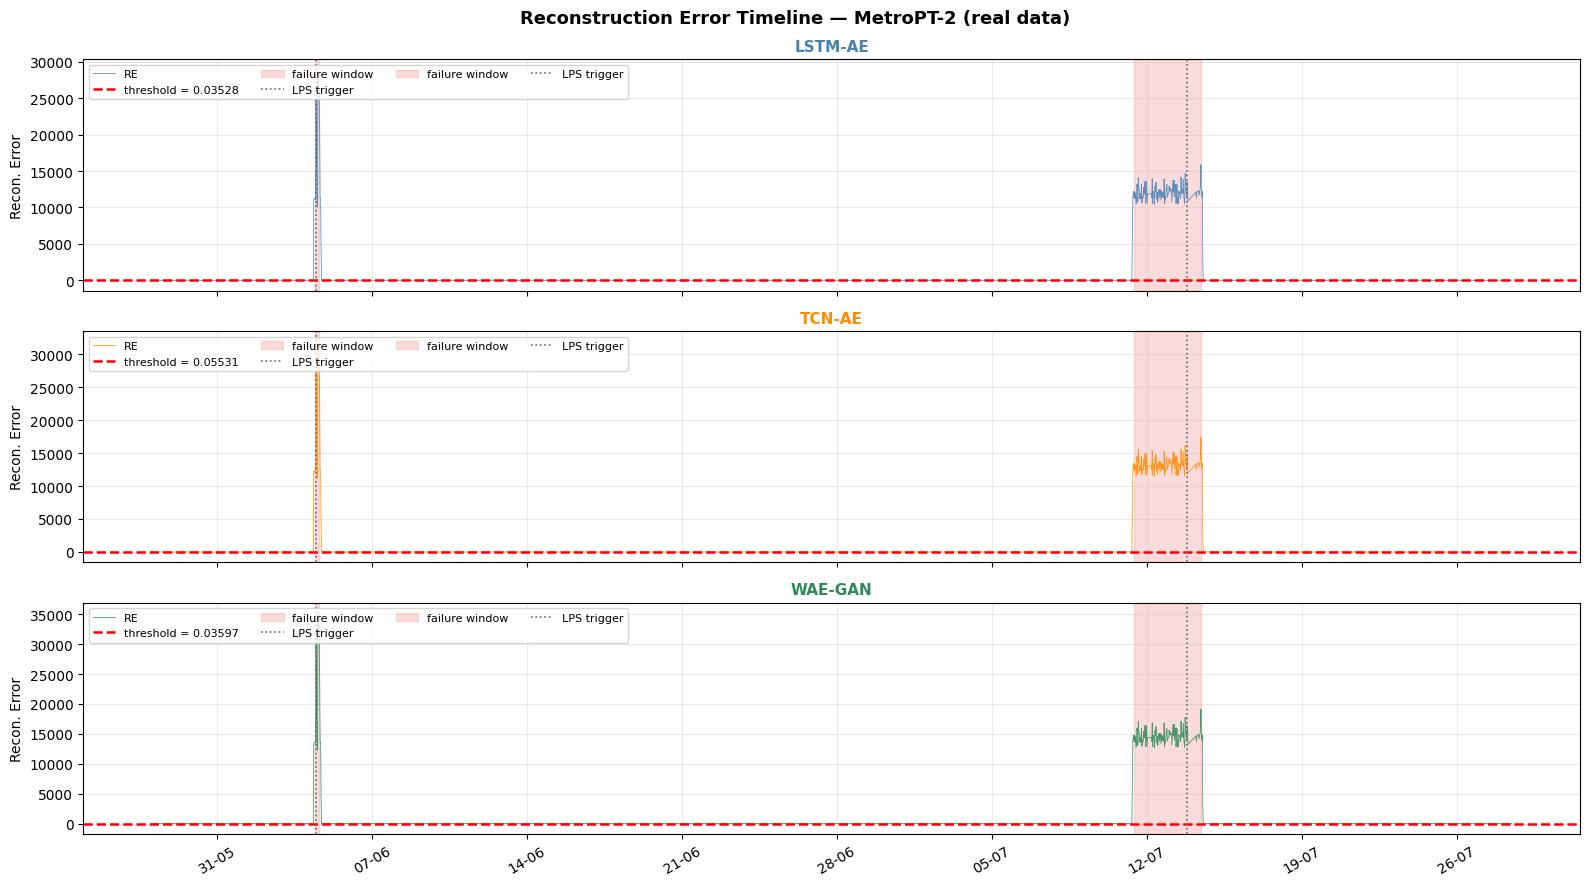

✓ re_timeline.png saved


In [ ]:
# ─── 7.1 Reconstruction-error timeline ────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
ts_pd = pd.DatetimeIndex(ts_arr)

re_info = [
    ('LSTM-AE', re_te_lstm, th_lstm, 'steelblue'),
    ('TCN-AE',  re_te_tcn,  th_tcn,  'darkorange'),
    ('WAE-GAN', re_te_wae,  th_wae,  'seagreen'),
]

for ax, (nm, re, thr, col) in zip(axes, re_info):
    ax.plot(ts_pd, re, lw=0.6, color=col, alpha=0.85, label='RE')
    ax.axhline(thr, color='red', ls='--', lw=1.8,
               label=f'threshold = {thr:.5f}')
    for _, row in MAINTENANCE.iterrows():
        ax.axvspan(row['start'], row['end'],
                   color='lightcoral', alpha=0.28, label='failure window')
        ax.axvline(row['lps'], color='dimgray', ls=':', lw=1.2,
                   label='LPS trigger')
    ax.set_title(nm, color=col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left', ncol=4)
    ax.grid(True, alpha=0.25)
    ax.set_ylabel('Recon. Error')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
plt.suptitle('Reconstruction Error Timeline — MetroPT-2 (real data)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('re_timeline.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ re_timeline.png saved")


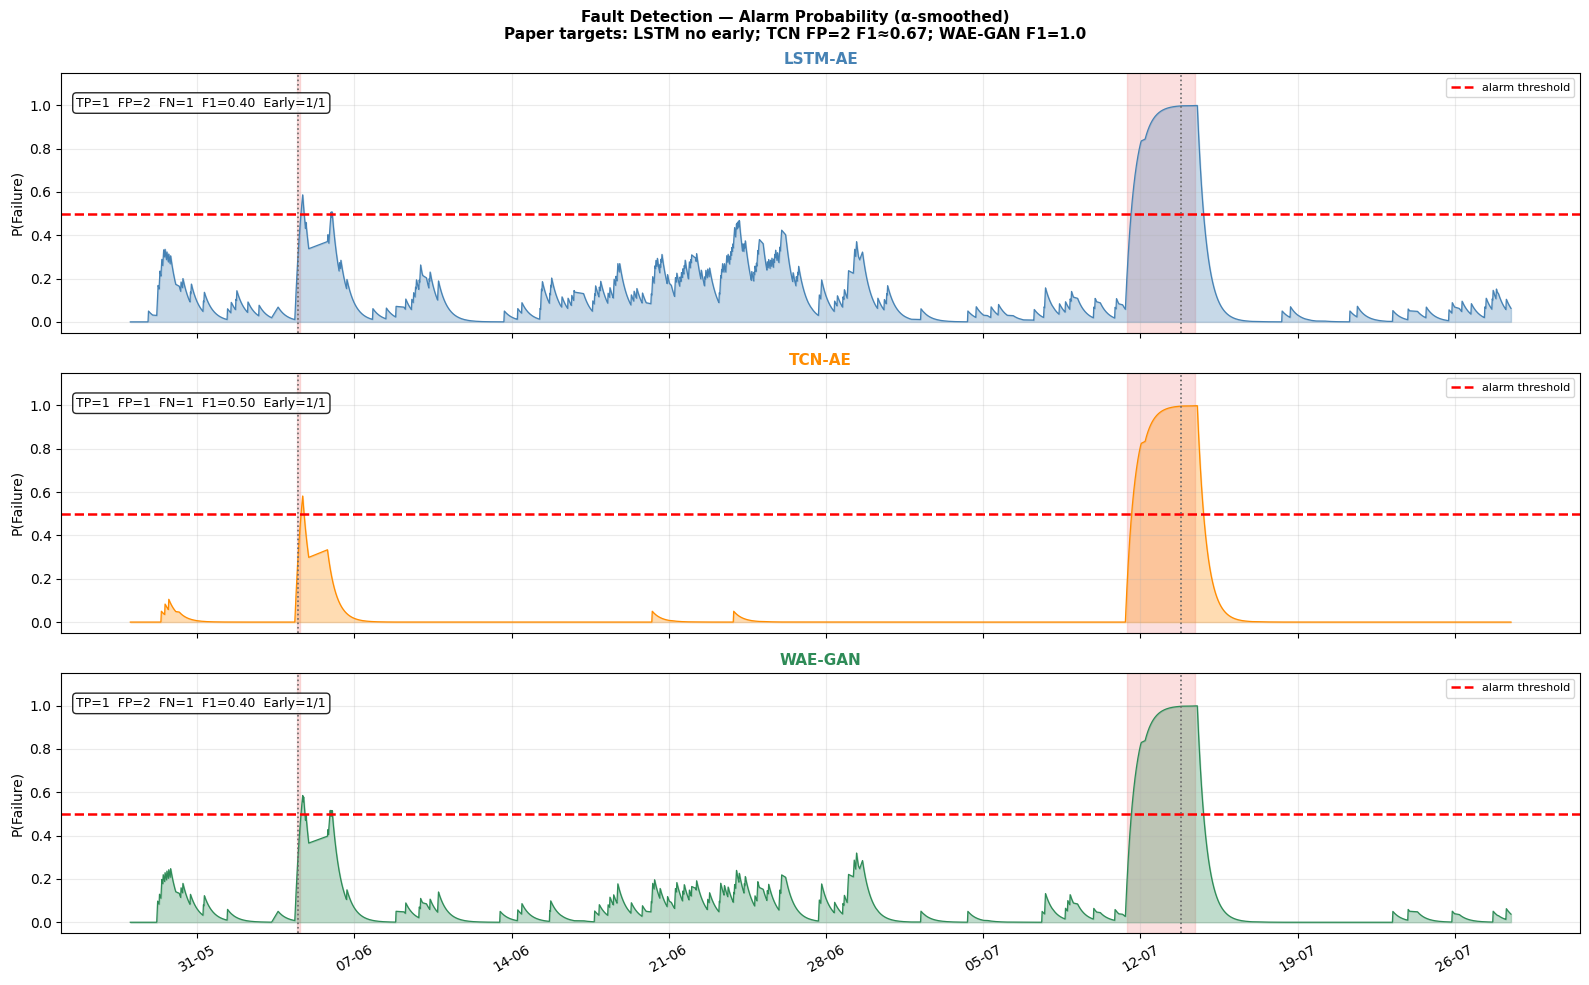

✓ alarm_probability.png saved


In [ ]:
# ─── 7.2 Alarm probability (fault detection output) ───────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

alarm_info = [
    ('LSTM-AE',  prob_lstm, 'steelblue',  ev_lstm),
    ('TCN-AE',   prob_tcn,  'darkorange', ev_tcn),
    ('WAE-GAN',  prob_wae,  'seagreen',   ev_wae),
]

for ax, (nm, prob, col, ev) in zip(axes, alarm_info):
    ax.fill_between(ts_pd, prob, alpha=0.30, color=col)
    ax.plot(ts_pd, prob, lw=0.9, color=col)
    ax.axhline(0.5, color='red', ls='--', lw=1.8, label='alarm threshold')

    for _, row in MAINTENANCE.iterrows():
        ax.axvspan(row['start'], row['end'],
                   color='lightcoral', alpha=0.25, zorder=0)
        ax.axvline(row['lps'], color='dimgray', ls=':', lw=1.2)

    summary = (f"TP={ev['tp']}  FP={ev['fp']}  FN={ev['fn']}  "
               f"F1={ev['f1']:.2f}  Early={ev['early']}/{ev['tp']}")
    ax.text(0.01, 0.87, summary, transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.set_ylim(-0.05, 1.15)
    ax.set_ylabel('P(Failure)')
    ax.set_title(nm, fontsize=11, color=col, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.25)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
plt.suptitle(
    'Fault Detection — Alarm Probability (α-smoothed)\n'
    'Paper targets: LSTM no early; TCN FP=2 F1≈0.67; WAE-GAN F1=1.0',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('alarm_probability.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ alarm_probability.png saved")


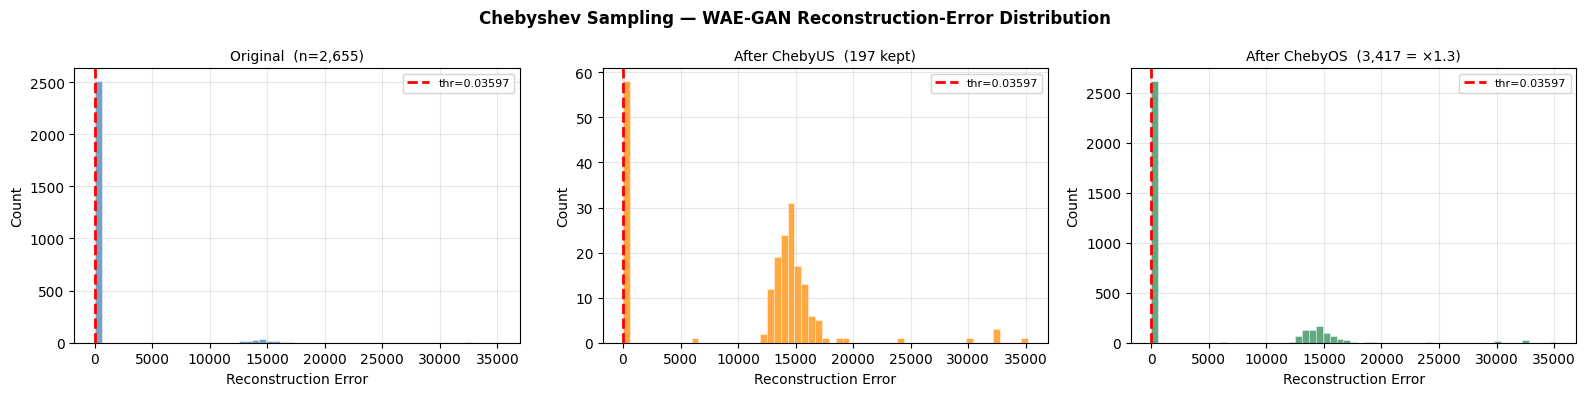

✓ chebyshev_sampling.png saved


In [ ]:
# ─── 7.3 Chebyshev sampling distribution (WAE-GAN RE) ────────────────────
us_sampler = ChebyUS()
kept        = np.array([us_sampler.keep(y) for y in re_te_wae])

os_sampler  = ChebyOS()
copies      = np.array([os_sampler.copies(y) for y in re_te_wae])
re_os       = np.repeat(re_te_wae, copies)

bins = np.linspace(re_te_wae.min(), re_te_wae.max(), 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_data = [
    (re_te_wae, 'steelblue',
     f'Original  (n={len(re_te_wae):,})'),
    (re_te_wae[kept], 'darkorange',
     f'After ChebyUS  ({kept.sum():,} kept)'),
    (re_os, 'seagreen',
     f'After ChebyOS  ({len(re_os):,} = ×{len(re_os)/len(re_te_wae):.1f})'),
]

for ax, (data, col, lbl) in zip(axes, plot_data):
    ax.hist(data, bins=bins, color=col, alpha=0.75,
            edgecolor='white', linewidth=0.4)
    ax.axvline(th_wae, color='red', ls='--', lw=2, label=f'thr={th_wae:.5f}')
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel('Reconstruction Error')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Chebyshev Sampling — WAE-GAN Reconstruction-Error Distribution',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chebyshev_sampling.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ chebyshev_sampling.png saved")


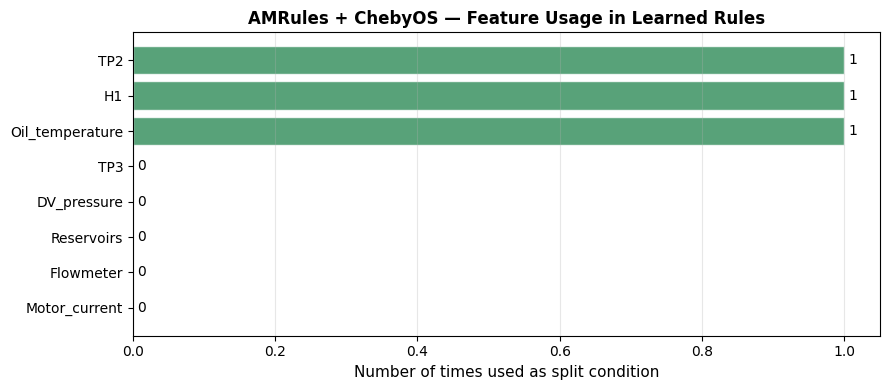

✓ feature_importance.png saved


In [ ]:
# ─── 7.4 Feature importance from AMRules conditions ──────────────────────
feat_counts = {f: 0 for f in FEATURES}
for r in amr_os.rules:
    for c in r.conds:
        feat_counts[c.feat] += 1

sorted_feats  = sorted(feat_counts, key=feat_counts.get, reverse=True)
sorted_counts = [feat_counts[f] for f in sorted_feats]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(sorted_feats, sorted_counts, color='seagreen', alpha=0.8,
               edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel('Number of times used as split condition', fontsize=11)
ax.set_title('AMRules + ChebyOS — Feature Usage in Learned Rules',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ feature_importance.png saved")
